In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import shutil
import os

cache_paths = [
    "/tmp/train_cache",
    "/tmp/val_cache",
    "/tmp/test_cache"
]
# Clear any existing lockfiles for the cache paths
for cache_path in cache_paths:
    lockfile_path = f"{cache_path}_0.lockfile"
    if os.path.exists(lockfile_path):
        os.remove(lockfile_path)


#Imported all the Required Tools for Building a Model along with Calculating and Evaluating the Model

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import seaborn as sns

import time
from tensorflow.keras.optimizers import SGD, Adam # Added Adam import

In [ ]:
def make_callbacks(checkpoint_path):
    return [
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, mode='min', verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-5, verbose=1)
    ]

# ── Shared evaluation helper ────────────────────────────────────────────────
def evaluate_model(model, dataset, class_names, title="Model"):
    y_true, y_pred = [], []
    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        predicted_labels = np.argmax(preds, axis=1)
        y_pred.extend(predicted_labels)
        y_true.extend(labels.numpy())

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
    plt.title(f'{title} — Confusion Matrix')
    plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.tight_layout(); plt.show()

    # Classification report
    print(f'\n{title} — Classification Report')
    print(classification_report(y_true, y_pred,
                                labels=list(range(len(class_names))),
                                target_names=class_names))
    return y_true, y_pred

# ── Training time wrapper ────────────────────────────────────────────────────
def train_and_time(model, train_ds, val_ds, epochs, callbacks):
    start = time.time()
    history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, callbacks=callbacks)
    elapsed = time.time() - start
    mins, secs = divmod(int(elapsed), 60)
    print(f'\n⏱  Total training time: {mins}m {secs}s ({elapsed:.1f}s)')
    return history, elapsed

# ── Accuracy + Loss plot helper ──────────────────────────────────────────────
def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(history.history['accuracy'], label='Train')
    ax1.plot(history.history['val_accuracy'], label='Validation')
    ax1.set_title(f'{title} — Accuracy'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax2.plot(history.history['loss'], label='Train')
    ax2.plot(history.history['val_loss'], label='Validation')
    ax2.set_title(f'{title} — Loss'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
    ax2.legend()
    plt.tight_layout(); plt.show()

#Defined a Fixed Image size and Batch Size to Work on

In [ ]:
img_size = (224, 224)
batch_size = 32

#Imported all the Data needed to Work

In [ ]:
train_dir = "/content/drive/MyDrive/AI Sem6/FruitsClassification/train"
valid_dir = "/content/drive/MyDrive/AI Sem6/FruitsClassification/valid"
test_dir = "/content/drive/MyDrive/AI Sem6/FruitsClassification/test"

#Loading all the Images from the folder to work on Neural Network

In [ ]:
Train_Dataset = keras.utils.image_dataset_from_directory(train_dir, image_size = img_size, batch_size = batch_size, )
Validation_Dataset = keras.utils.image_dataset_from_directory(valid_dir, image_size = img_size, batch_size = batch_size)
Test_Dataset = keras.utils.image_dataset_from_directory(test_dir, image_size = img_size, batch_size = batch_size)

Found 9709 files belonging to 5 classes.
Found 200 files belonging to 5 classes.
Found 100 files belonging to 5 classes.


## Dataset Description

This project focuses on **fruit image classification**. The dataset is organized into `train`, `valid`, and `test` splits to ensure robust model evaluation, preventing data leakage and providing an unbiased assessment of the model's generalization capabilities.

### Preprocessing:

*   **Resizing**: All images are resized to `224x224` pixels to standardize input dimensions for the neural networks.
*   **Rescaling**: Pixel values are rescaled from the original `[0, 255]` range to `[0, 1]` by dividing by 255. This normalization helps the model converge faster and perform better.

### Augmentation:

To improve the model's ability to generalize and reduce overfitting, the following data augmentation techniques are applied to the training dataset:

*   **RandomFlip**: Images are randomly flipped horizontally and vertically.
*   **RandomRotation**: Images are randomly rotated by up to 20% of a full circle.
*   **RandomZoom**: Images are randomly zoomed in or out by up to 20%.

These augmentations create variations of the training images, making the model more robust to different orientations, sizes, and perspectives of the fruit images.

In [ ]:
Class_Names = Train_Dataset.class_names
Num_Classes = len(Class_Names)
print("Classes:", Class_Names)
print("Number of classes:", Num_Classes)

Classes: ['Apple', 'Banana', 'Grape', 'Mango', 'Strawberry']
Number of classes: 5


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE
normalization_layer = keras.layers.Rescaling(1./255)

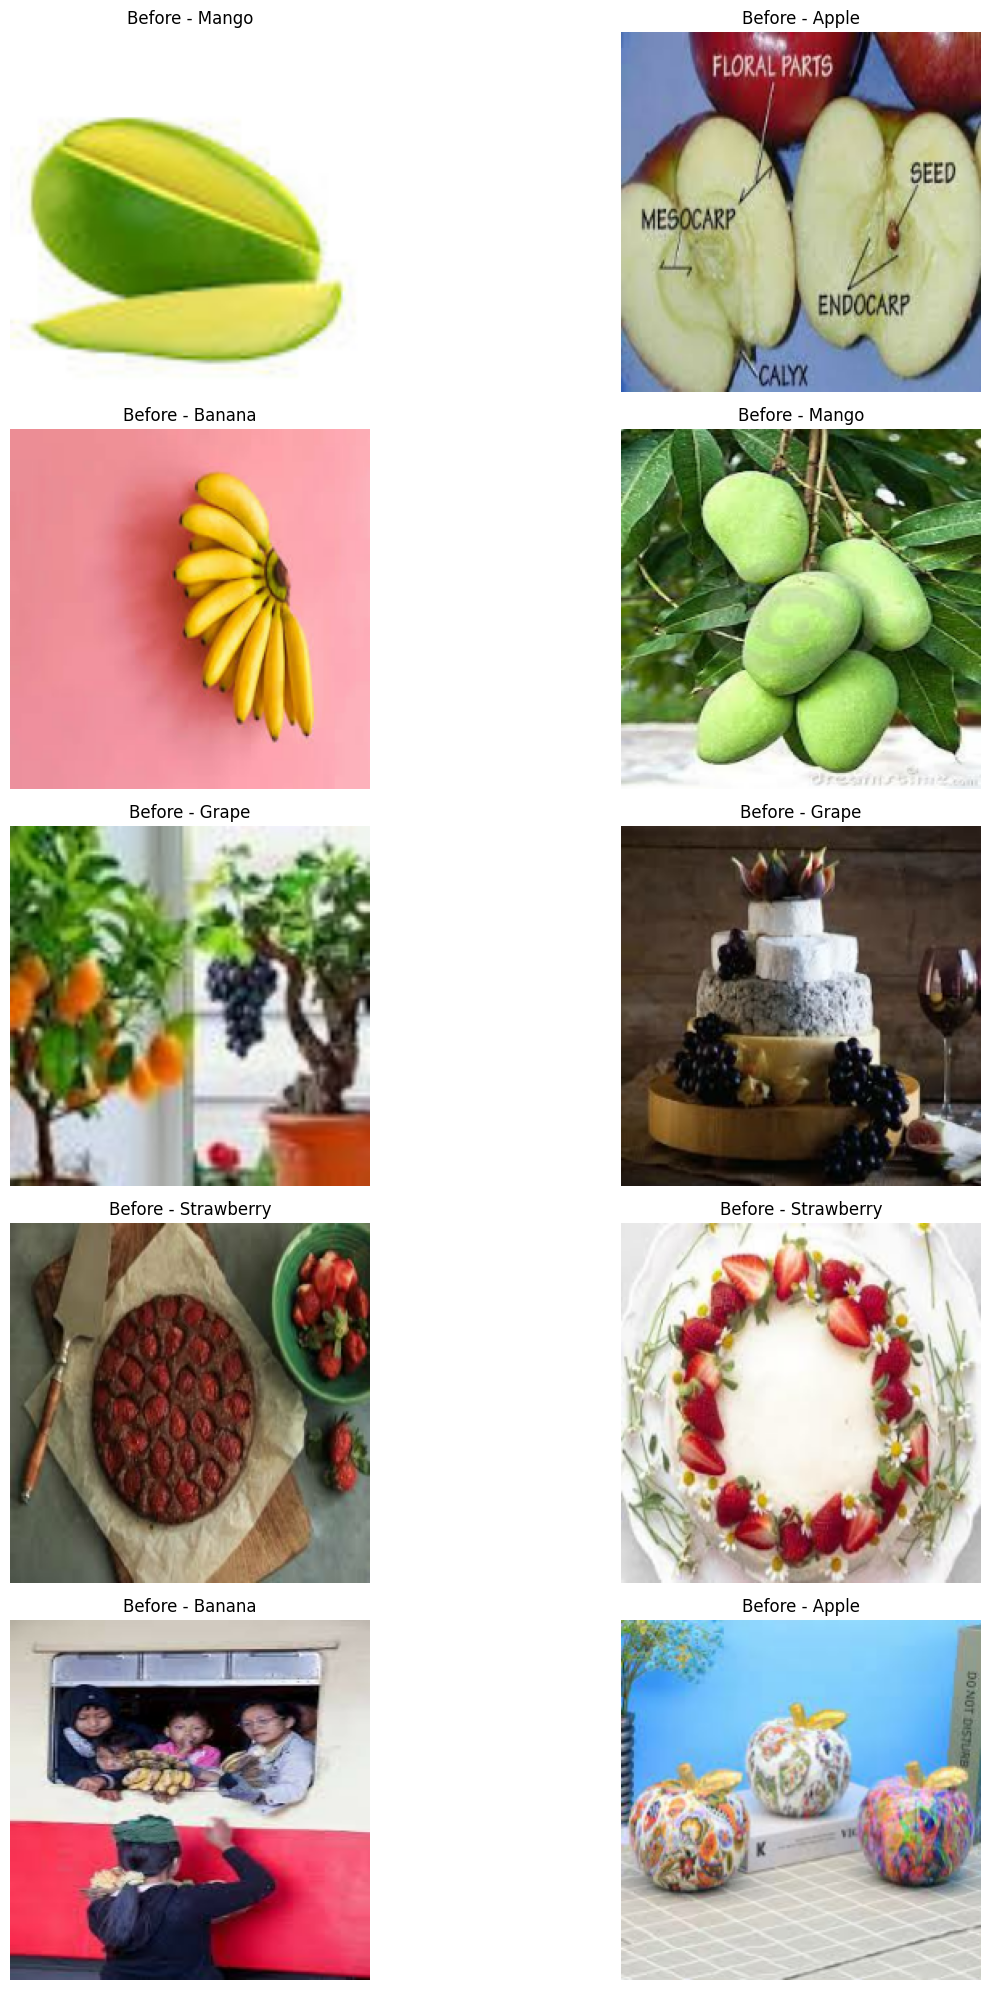

In [ ]:
plt.figure(figsize=(15, 20))

images_per_class = 2
shown_count = {class_name: 0 for class_name in Class_Names}
plot_index = 1

for images, labels in Train_Dataset:

    for i in range(len(images)):

        class_name = Class_Names[labels[i]]

        if shown_count[class_name] < images_per_class:

            plt.subplot(
                Num_Classes,
                images_per_class,
                plot_index
            )

            plt.imshow(images[i].numpy().astype("uint8"))
            plt.title(f"Before - {class_name}")
            plt.axis("off")

            shown_count[class_name] += 1
            plot_index += 1

    if all(count == images_per_class for count in shown_count.values()):
        break

plt.tight_layout()
plt.show()

In [ ]:
Data_Augmentation_Part2 = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
], name="aug_part2")

In [ ]:
Data_Augmentation_Scratch = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
], name="aug_scratch")

## Augmented Image Visualization

To better understand the effect of the data augmentation layers, let's visualize some samples from the training dataset after applying these augmentations. This helps confirm that the transformations are being applied as expected and to observe the variety introduced into the training data.

In [ ]:
Train_Dataset = Train_Dataset.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=AUTOTUNE
)
Validation_Dataset = Validation_Dataset.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=AUTOTUNE
)
Test_Dataset = Test_Dataset.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=AUTOTUNE
)

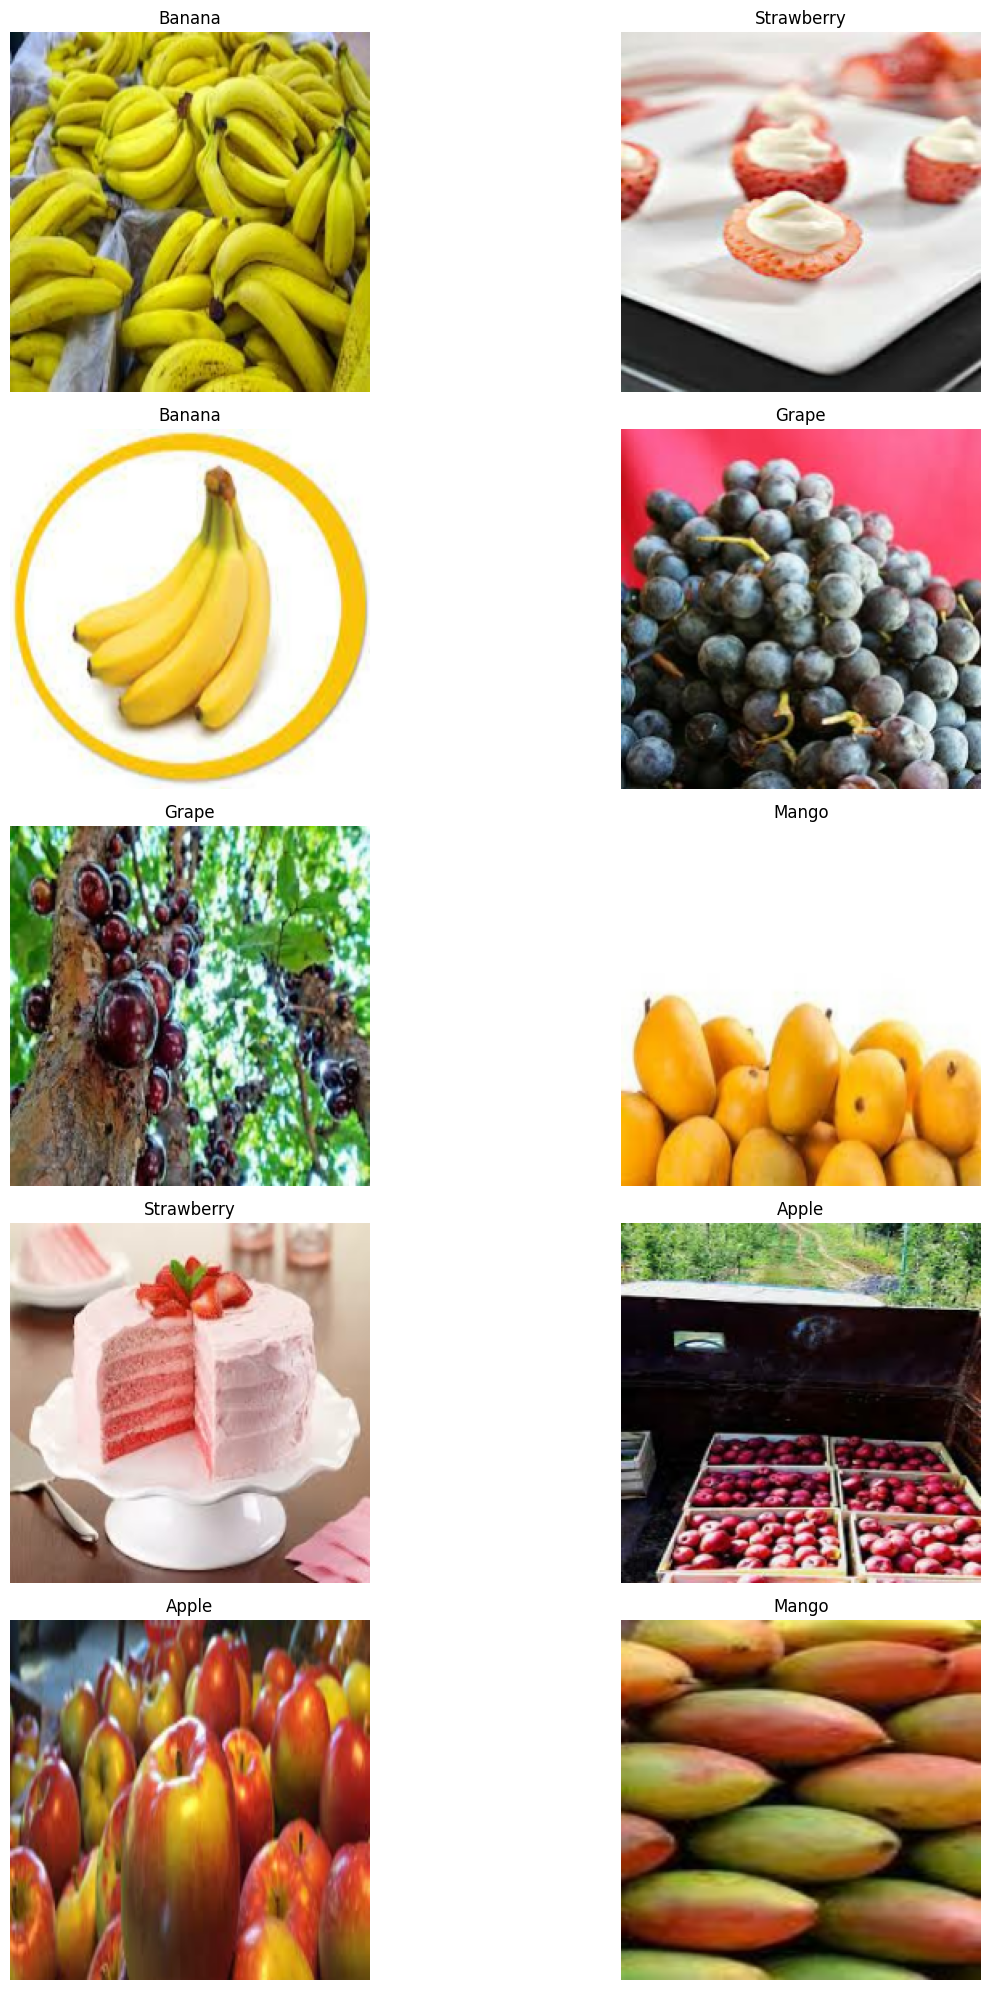

In [ ]:
plt.figure(figsize=(15, 20))

images_per_class = 2
shown_count = {class_name: 0 for class_name in Class_Names}

plot_index = 1

for images, labels in Train_Dataset:

    for i in range(len(images)):

        class_name = Class_Names[labels[i]]

        if shown_count[class_name] < images_per_class:

            ax = plt.subplot(
                Num_Classes,
                images_per_class,
                plot_index
            )

            plt.imshow(images[i].numpy())
            plt.title(class_name)
            plt.axis("off")

            shown_count[class_name] += 1
            plot_index += 1

    # Stop when all classes have 2 images
    if all(count == images_per_class for count in shown_count.values()):
        break

plt.tight_layout()
plt.show()

In [ ]:
Train_Dataset = Train_Dataset.shuffle(1000, reshuffle_each_iteration=True).cache().prefetch(AUTOTUNE)
Validation_Dataset = Validation_Dataset.cache("/tmp/val_cache").prefetch(AUTOTUNE)
Test_Dataset = Test_Dataset.cache("/tmp/test_cache").prefetch(AUTOTUNE)

In [ ]:
base_model = keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

In [ ]:
Part2Model = keras.Sequential([
    layers.Input(shape=(224, 224, 3)),
    Data_Augmentation_Part2,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(Num_Classes, activation="softmax")
])

In [ ]:
Part2Model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/WORk/AI2/archive/best_Part2_fruit_model.keras",
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

In [ ]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=0.00001,
    verbose=1
)

In [ ]:
history, time_part2 = train_and_time(
    Part2Model,
    Train_Dataset,
    Validation_Dataset,
    epochs=40,
    callbacks=[
        early_stop,
        checkpoint,
        reduce_lr
    ]
)

Epoch 1/40
304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.6316 - loss: 0.9995
Epoch 1: val_loss improved from None to 0.39205, saving model to /content/drive/MyDrive/WORk/AI2/archive/best_Part2_fruit_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/WORk/AI2/archive/best_Part2_fruit_model.keras
304/304 ━━━━━━━━━━━━━━━━━━━━ 1434s 197ms/step - accuracy: 0.7215 - loss: 0.7708 - val_accuracy: 0.8700 - val_loss: 0.3921 - learning_rate: 5.0000e-04
Epoch 2/40
304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.7998 - loss: 0.5491
Epoch 2: val_loss improved from 0.39205 to 0.37712, saving model to /content/drive/MyDrive/WORk/AI2/archive/best_Part2_fruit_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/WORk/AI2/archive/best_Part2_fruit_model.keras
304/304 ━━━━━━━━━━━━━━━━━━━━ 55s 70ms/step - accuracy: 0.8025 - loss: 0.5447 - val_accuracy: 0.8450 - val_loss: 0.3771 - learning_rate: 5.0000e-04
Epoch 3/40
304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/st

In [ ]:
import os
for name, path in [("Train", train_dir), ("Valid", valid_dir), ("Test", test_dir)]:
    total = sum(len(files) for _, _, files in os.walk(path))
    print(f"{name}: {total} images")
    for class_folder in os.listdir(path):
        class_path = os.path.join(path, class_folder)
        if os.path.isdir(class_path):
            count = len(os.listdir(class_path))
            print(f"  {class_folder}: {count} images")

Train: 9709 images
  Apple: 1940 images
  Grape: 1940 images
  Banana: 1940 images
  Mango: 1949 images
  Strawberry: 1940 images
Valid: 200 images
  Strawberry: 40 images
  Mango: 40 images
  Grape: 40 images
  Banana: 40 images
  Apple: 40 images
Test: 100 images
  Mango: 20 images
  Strawberry: 20 images
  Grape: 20 images
  Banana: 20 images
  Apple: 20 images


In [ ]:
print(test_dir)
print(valid_dir)

/content/drive/MyDrive/WORk/AI2/archive/FruitsClassification/test
/content/drive/MyDrive/WORk/AI2/archive/FruitsClassification/valid


In [ ]:
Part2Model = keras.models.load_model(
    "/content/drive/MyDrive/AI Sem6/FruitsClassification/best_Part2_fruit_model.keras"
)

# Then reload test dataset fresh
Test_Dataset = keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=img_size,
    batch_size=batch_size
)
Test_Dataset = Test_Dataset.map(lambda x, y: (normalization_layer(x), y))
Test_Dataset = Test_Dataset.prefetch(buffer_size=AUTOTUNE)

# Now evaluate
test_loss, test_accuracy = Part2Model.evaluate(Test_Dataset)
print("Test Accuracy:", test_accuracy)

Found 100 files belonging to 5 classes.
4/4 ━━━━━━━━━━━━━━━━━━━━ 27s 5s/step - accuracy: 0.9000 - loss: 0.2473
Test Accuracy: 0.8999999761581421


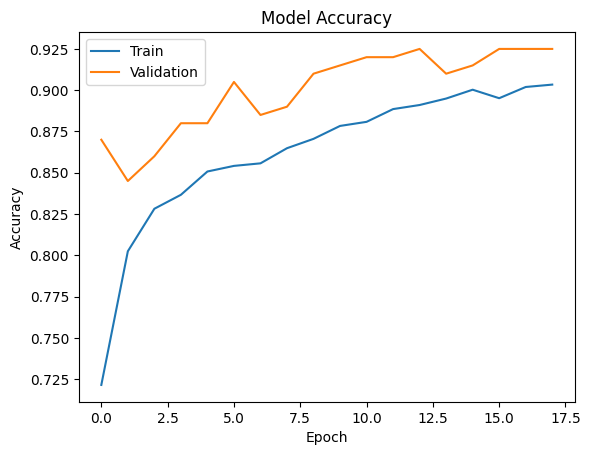

In [ ]:
# Note: 'history' must be from the current session for plotting to work correctly.
# If the kernel was reset, 'history' might be undefined or stale.
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train", "Validation"])

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


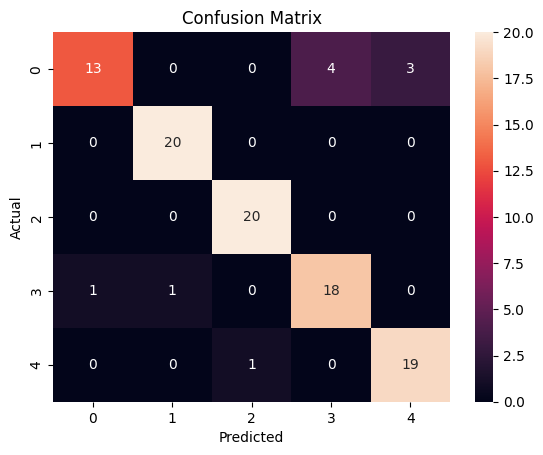

In [ ]:
y_true = []
y_pred = []

for images, labels in Test_Dataset:
    predictions = Part2Model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

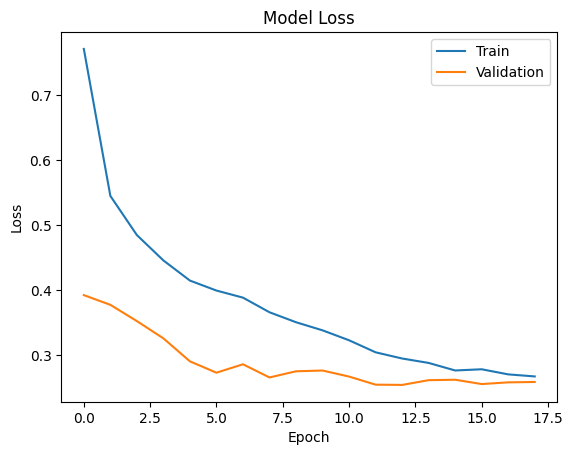

In [ ]:
# Note: 'history' must be from the current session for plotting to work correctly.
# If the kernel was reset, 'history' might be undefined or stale.
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Train", "Validation"])

plt.show()

In [ ]:
print("Train classes:", Class_Names)
print("Unique predictions:", set(y_pred))
print("Unique true labels:", set(y_true))

Train classes: ['Apple', 'Banana', 'Grape', 'Mango', 'Strawberry']
Unique predictions: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)}
Unique true labels: {np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4)}


In [ ]:
print(classification_report(
    y_true,
    y_pred,
    labels=list(range(Num_Classes)),  # ← fixes the ValueError
    target_names=Class_Names
))

              precision    recall  f1-score   support

       Apple       0.93      0.65      0.76        20
      Banana       0.95      1.00      0.98        20
       Grape       0.95      1.00      0.98        20
       Mango       0.82      0.90      0.86        20
  Strawberry       0.86      0.95      0.90        20

    accuracy                           0.90       100
   macro avg       0.90      0.90      0.90       100
weighted avg       0.90      0.90      0.90       100



## Scratch Model

## New Baseline CNN Model

This section introduces a simple baseline Convolutional Neural Network (CNN) model to establish a performance benchmark. It consists of three convolutional blocks followed by a global average pooling layer and three dense layers, culminating in a softmax output for classification. This model serves as a foundation for comparison with more complex architectures.

In [ ]:
from tensorflow.keras.optimizers import Adam

Baseline_CNN = keras.Sequential([
    layers.Input(shape=(img_size[0], img_size[1], 3)),
    Data_Augmentation_Scratch, # Using the same augmentation as the scratch model

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.GlobalAveragePooling2D(),

    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(Num_Classes, activation='softmax')
])

Baseline_CNN.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

### Baseline CNN Model Summary

The `model.summary()` below provides a concise overview of the Baseline CNN's architecture, listing each layer, its output shape, and the number of trainable parameters. This is crucial for understanding the model's complexity and how features are transformed through the network.

In [ ]:
print("Baseline CNN Model Summary:")
Baseline_CNN.summary()
print("\nThis summary shows the layer structure and parameter count for the Baseline CNN model.")

Baseline CNN Model Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ aug_scratch (Sequential)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,749 (655.27 KB)

 Trainable params: 167,749 (655.27 KB)

 Non-trainable params: 0 (0.00 B)


This summary shows the layer structure and parameter count for the Baseline CNN model.


### Training the Baseline CNN Model

Now, we will train the Baseline CNN model using the specified callbacks and measure its training time. The `train_and_time` helper function will be used to encapsulate the training process and report the elapsed time.

In [ ]:
baseline_callbacks = make_callbacks('/content/drive/MyDrive/WORk/AI2/archive/baseline_model.keras')
history_baseline, time_baseline = train_and_time(
    Baseline_CNN,
    Train_Dataset,
    Validation_Dataset,
    epochs=40,
    callbacks=baseline_callbacks
)

Epoch 1/40
303/304 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.3298 - loss: 1.4668
Epoch 1: val_loss improved from None to 1.18977, saving model to /content/drive/MyDrive/WORk/AI2/archive/baseline_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/WORk/AI2/archive/baseline_model.keras
304/304 ━━━━━━━━━━━━━━━━━━━━ 21s 53ms/step - accuracy: 0.4133 - loss: 1.3302 - val_accuracy: 0.4650 - val_loss: 1.1898 - learning_rate: 5.0000e-04
Epoch 2/40
304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.5314 - loss: 1.1444
Epoch 2: val_loss improved from 1.18977 to 1.11702, saving model to /content/drive/MyDrive/WORk/AI2/archive/baseline_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/WORk/AI2/archive/baseline_model.keras
304/304 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step - accuracy: 0.5415 - loss: 1.1210 - val_accuracy: 0.5150 - val_loss: 1.1170 - learning_rate: 5.0000e-04
Epoch 3/40
304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.5581 - loss: 1.075

### Evaluating the Baseline CNN Model

After training, the Baseline CNN model will be evaluated on the test dataset to assess its performance. This includes calculating test accuracy, generating a confusion matrix, and providing a classification report. The `plot_history` function will visualize the accuracy and loss curves during training.

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 171ms/step - accuracy: 0.7400 - loss: 0.6485
Baseline CNN Test Accuracy: 0.7400


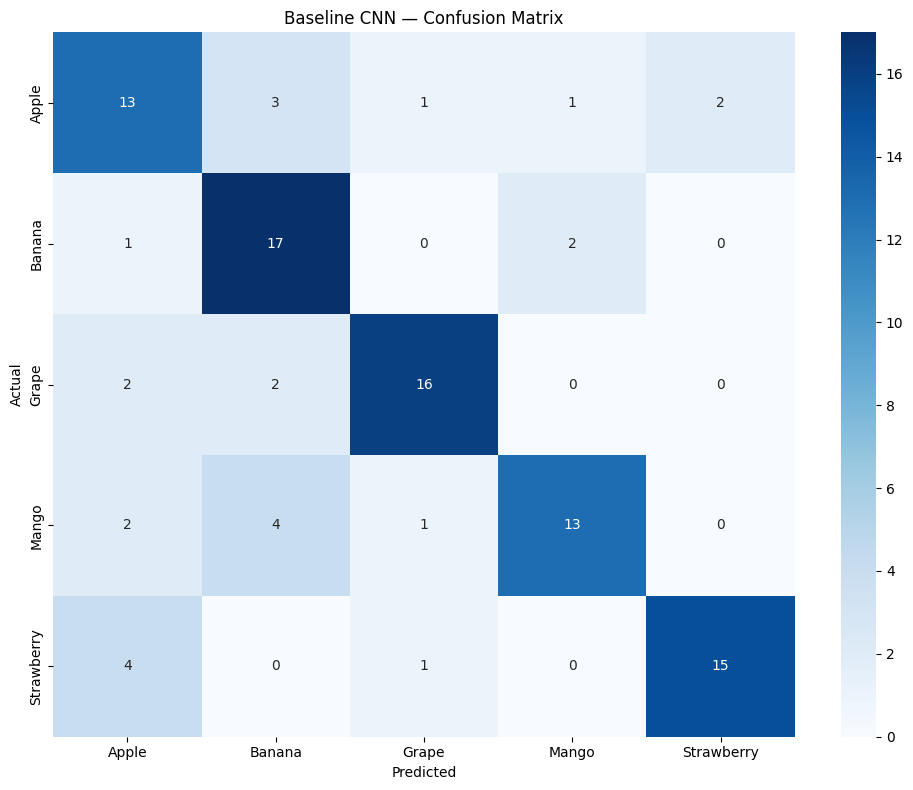


Baseline CNN — Classification Report
              precision    recall  f1-score   support

       Apple       0.59      0.65      0.62        20
      Banana       0.65      0.85      0.74        20
       Grape       0.84      0.80      0.82        20
       Mango       0.81      0.65      0.72        20
  Strawberry       0.88      0.75      0.81        20

    accuracy                           0.74       100
   macro avg       0.76      0.74      0.74       100
weighted avg       0.76      0.74      0.74       100



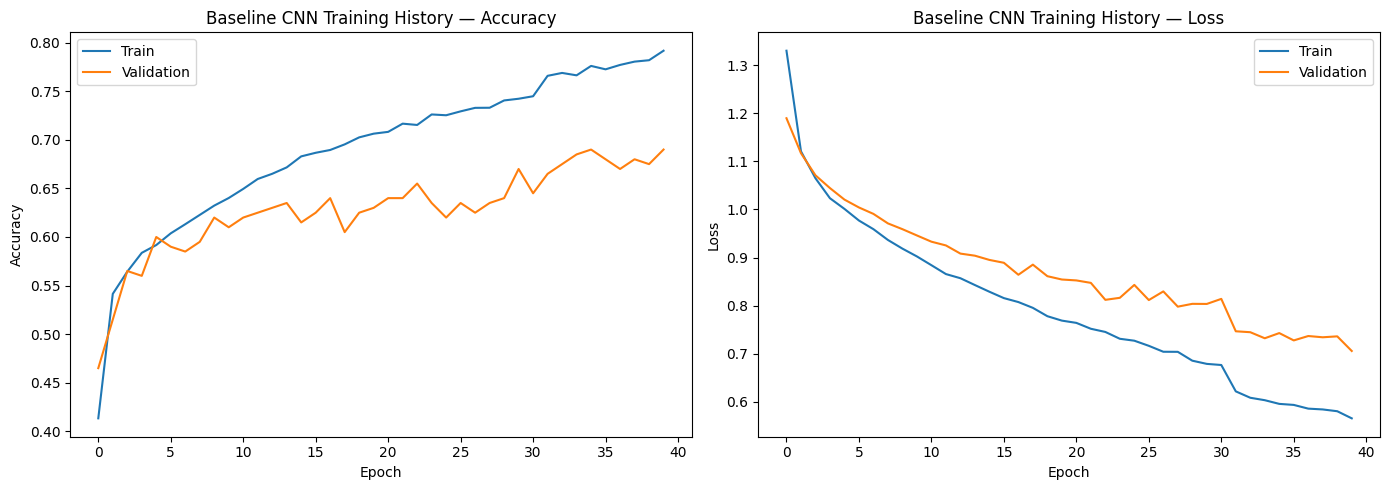

In [ ]:
Baseline_CNN = keras.models.load_model(
    '/content/drive/MyDrive/AI Sem6/FruitsClassification/baseline_model.keras'
)

test_loss_baseline, test_accuracy_baseline = Baseline_CNN.evaluate(Test_Dataset)
print(f"Baseline CNN Test Accuracy: {test_accuracy_baseline:.4f}")

y_true_baseline, y_pred_baseline = evaluate_model(Baseline_CNN, Test_Dataset, Class_Names, title="Baseline CNN")

plot_history(history_baseline, title="Baseline CNN Training History")

In [ ]:
Model = keras.Sequential([
    layers.Input(shape=(224, 224, 3)),

    Data_Augmentation_Scratch,

    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.Conv2D(128, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(256, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    layers.Dense(Num_Classes, activation="softmax")
])


### Deeper Scratch Model Summary

The `model.summary()` for the deeper scratch model provides insights into its more complex architecture, including a larger number of layers, batch normalization, and dropout layers. This detailed view helps in understanding the increase in trainable parameters and the flow of data through the network compared to the baseline model.

In [ ]:
print("Deeper Scratch Model Summary:")
Model.summary()
print("\nThis summary details the layer structure and parameter count for the Deeper Scratch model.")

Deeper Scratch Model Summary:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ aug_scratch (Sequential)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 652,197 (2.49 MB)

 Trainable params: 650,725 (2.48 MB)

 Non-trainable params: 1,472 (5.75 KB)


This summary details the layer structure and parameter count for the Deeper Scratch model.


In [ ]:
Model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
# Use the make_callbacks helper function for consistency
scratch_callbacks = make_callbacks("/content/drive/MyDrive/AI Sem6/FruitsClassification/scratch_model.keras")

# Wrap the training with the timing function
history_scratch, time_scratch = train_and_time(
    Model,
    Train_Dataset,
    Validation_Dataset,
    epochs=50,
    callbacks=scratch_callbacks
)

Epoch 1/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.4241 - loss: 1.6373
Epoch 1: val_loss improved from None to 1.72633, saving model to /content/drive/MyDrive/WORk/AI2/archive/scratch_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/WORk/AI2/archive/scratch_model.keras
304/304 ━━━━━━━━━━━━━━━━━━━━ 73s 212ms/step - accuracy: 0.4695 - loss: 1.4453 - val_accuracy: 0.2500 - val_loss: 1.7263 - learning_rate: 5.0000e-04
Epoch 2/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.5331 - loss: 1.2150
Epoch 2: val_loss improved from 1.72633 to 1.27604, saving model to /content/drive/MyDrive/WORk/AI2/archive/scratch_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/WORk/AI2/archive/scratch_model.keras
304/304 ━━━━━━━━━━━━━━━━━━━━ 62s 204ms/step - accuracy: 0.5510 - loss: 1.1684 - val_accuracy: 0.5450 - val_loss: 1.2760 - learning_rate: 5.0000e-04
Epoch 3/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.5825 - loss: 1.08

In [ ]:
Model = keras.models.load_model(
    "/content/drive/MyDrive/AI Sem6/FruitsClassification/scratch_model.keras"
)


In [ ]:
test_loss, test_accuracy = Model.evaluate(Test_Dataset)

print("Scratch Model Test Accuracy:", test_accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 254ms/step - accuracy: 0.8400 - loss: 0.4567
Scratch Model Test Accuracy: 0.8399999737739563


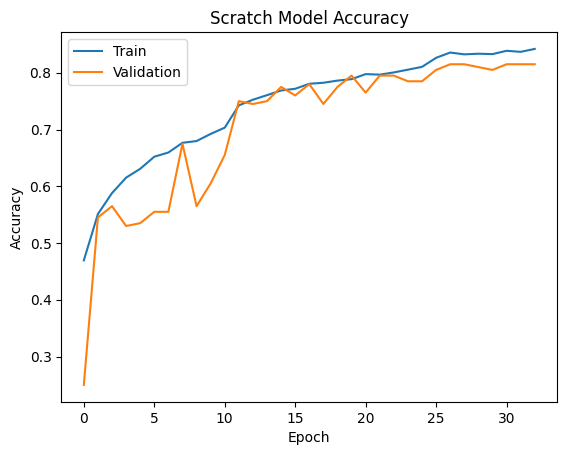

In [ ]:
# Note: 'history_scratch' must be from the current session for plotting to work correctly.
# If the kernel was reset or training interrupted, 'history_scratch' might be undefined or stale.
plt.plot(history_scratch.history['accuracy'])
plt.plot(history_scratch.history['val_accuracy'])

plt.title("Scratch Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train", "Validation"])

plt.show()

In [ ]:
y_true_scratch = []
y_pred_scratch = []

for images, labels in Test_Dataset:

    predictions = Model.predict(images)

    predicted_labels = np.argmax(predictions, axis=1)

    y_true_scratch.extend(labels.numpy())
    y_pred_scratch.extend(predicted_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step


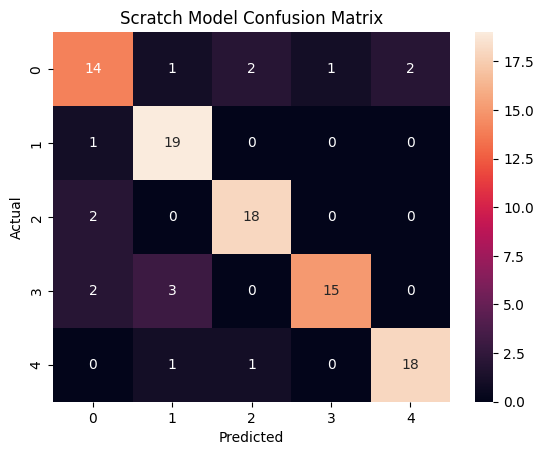

In [ ]:
cm_scratch = confusion_matrix(
    y_true_scratch,
    y_pred_scratch
)

sns.heatmap(cm_scratch, annot=True, fmt="d")

plt.title("Scratch Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

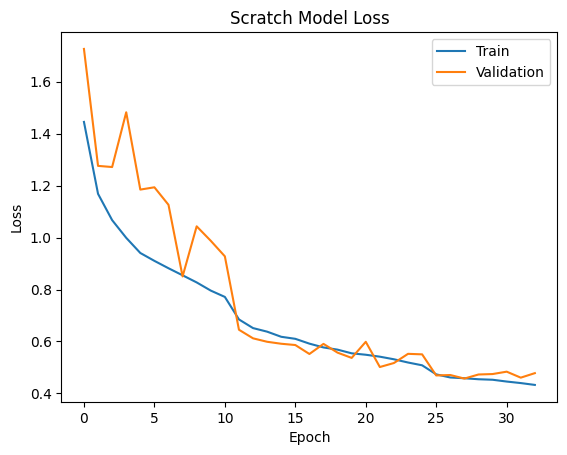

In [ ]:
# Note: 'history_scratch' must be from the current session for plotting to work correctly.
# If the kernel was reset or training interrupted, 'history_scratch' might be undefined or stale.
plt.plot(history_scratch.history['loss'])
plt.plot(history_scratch.history['val_loss'])

plt.title("Scratch Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Train", "Validation"])

plt.show()

In [ ]:
print("Scratch Model Classes:", Class_Names)

print("Unique predictions:", set(y_pred_scratch))

print("Unique true labels:", set(y_true_scratch))

print(classification_report(
    y_true_scratch,
    y_pred_scratch,
    labels=list(range(Num_Classes)),
    target_names=Class_Names
))

Scratch Model Classes: ['Apple', 'Banana', 'Grape', 'Mango', 'Strawberry']
Unique predictions: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)}
Unique true labels: {np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4)}
              precision    recall  f1-score   support

       Apple       0.74      0.70      0.72        20
      Banana       0.79      0.95      0.86        20
       Grape       0.86      0.90      0.88        20
       Mango       0.94      0.75      0.83        20
  Strawberry       0.90      0.90      0.90        20

    accuracy                           0.84       100
   macro avg       0.84      0.84      0.84       100
weighted avg       0.84      0.84      0.84       100



## 1. SGD vs Adam Comparison

This section compares the performance of the Deeper Scratch Model when trained with two different optimizers: SGD (Stochastic Gradient Descent) and Adam. We will train the same model architecture twice, once with each optimizer, and then analyze their training histories and final test accuracies.

### Training with SGD Optimizer


In [ ]:
def build_deeper_scratch_model(augmentation_layer, num_classes):
    model = keras.Sequential([
        layers.Input(shape=(224, 224, 3)),
        augmentation_layer,

        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(256, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.GlobalAveragePooling2D(),

        layers.Dense(256, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.4),

        layers.Dense(num_classes, activation="softmax")
    ])
    return model

sgd_model = build_deeper_scratch_model(Data_Augmentation_Scratch, Num_Classes)

sgd_model.compile(
    optimizer=SGD(learning_rate=0.001, momentum=0.9),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("SGD Model Summary:")
sgd_model.summary()

SGD Model Summary:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ aug_scratch (Sequential)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 652,197 (2.49 MB)

 Trainable params: 650,725 (2.48 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [ ]:
sgd_callbacks = make_callbacks("/content/drive/MyDrive/AI Sem6/FruitsClassification/sgd_deeper_scratch_model.keras")
history_sgd, time_sgd = train_and_time(
    sgd_model,
    Train_Dataset,
    Validation_Dataset,
    epochs=50,
    callbacks=sgd_callbacks
)

Epoch 1/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.4226 - loss: 1.5950
Epoch 1: val_loss improved from None to 1.74040, saving model to /content/drive/MyDrive/WORk/AI2/archive/sgd_deeper_scratch_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/WORk/AI2/archive/sgd_deeper_scratch_model.keras
304/304 ━━━━━━━━━━━━━━━━━━━━ 65s 205ms/step - accuracy: 0.4694 - loss: 1.4180 - val_accuracy: 0.2950 - val_loss: 1.7404 - learning_rate: 0.0010
Epoch 2/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.5401 - loss: 1.1768
Epoch 2: val_loss improved from 1.74040 to 1.11173, saving model to /content/drive/MyDrive/WORk/AI2/archive/sgd_deeper_scratch_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/WORk/AI2/archive/sgd_deeper_scratch_model.keras
304/304 ━━━━━━━━━━━━━━━━━━━━ 61s 202ms/step - accuracy: 0.5401 - loss: 1.1712 - val_accuracy: 0.5300 - val_loss: 1.1117 - learning_rate: 0.0010
Epoch 3/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.7000 - loss: 0.7107 
SGD Model Test Accuracy: 0.699999988079071


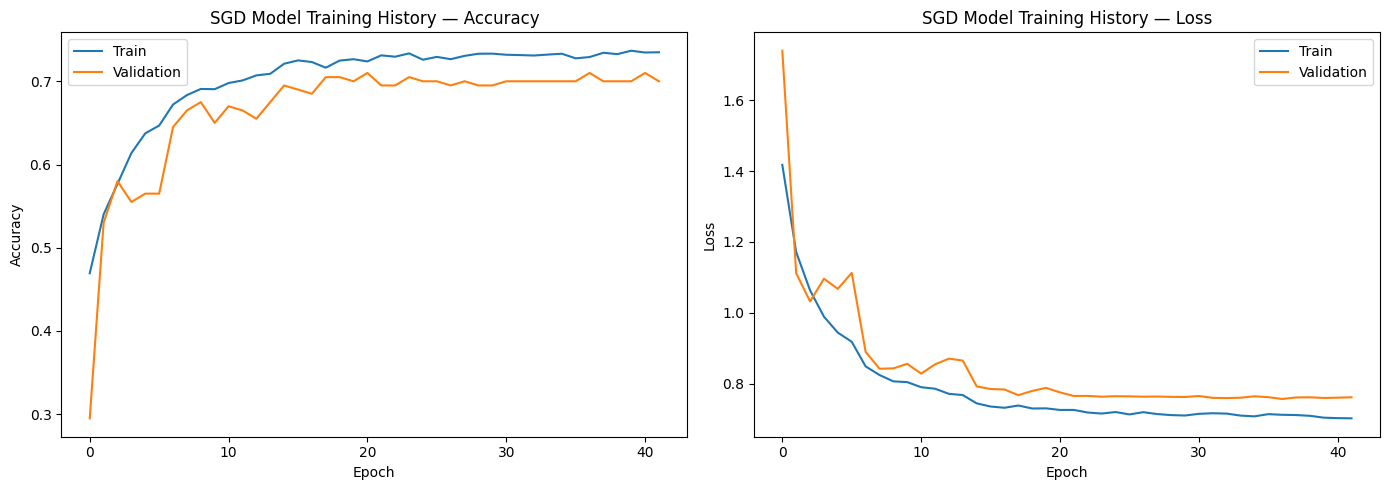

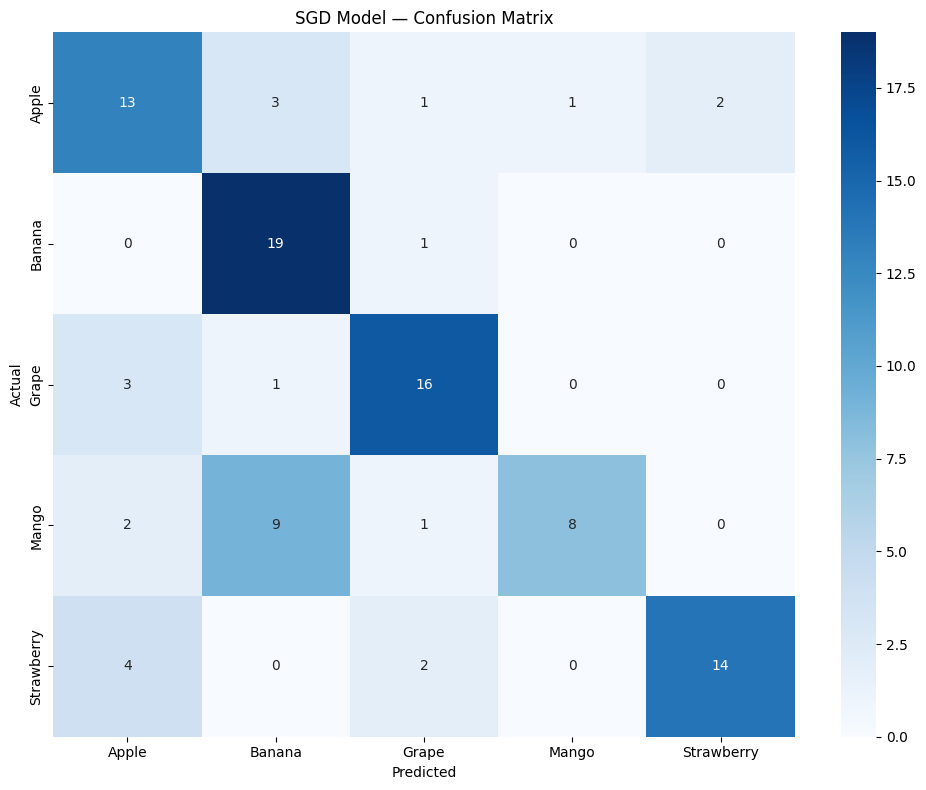


SGD Model — Classification Report
              precision    recall  f1-score   support

       Apple       0.59      0.65      0.62        20
      Banana       0.59      0.95      0.73        20
       Grape       0.76      0.80      0.78        20
       Mango       0.89      0.40      0.55        20
  Strawberry       0.88      0.70      0.78        20

    accuracy                           0.70       100
   macro avg       0.74      0.70      0.69       100
weighted avg       0.74      0.70      0.69       100



In [ ]:
sgd_model = keras.models.load_model(
    "/content/drive/MyDrive/AI Sem6/FruitsClassification/sgd_deeper_scratch_model.keras"
)

test_loss_sgd, test_accuracy_sgd = sgd_model.evaluate(Test_Dataset)
print("SGD Model Test Accuracy:", test_accuracy_sgd)

plot_history(history_sgd, title="SGD Model Training History")
y_true_sgd, y_pred_sgd = evaluate_model(sgd_model, Test_Dataset, Class_Names, title="SGD Model")

### Training with Adam Optimizer



In [ ]:
adam_model = build_deeper_scratch_model(Data_Augmentation_Scratch, Num_Classes)

adam_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Adam Model Summary:")
adam_model.summary()

Adam Model Summary:


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ aug_scratch (Sequential)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 652,197 (2.49 MB)

 Trainable params: 650,725 (2.48 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [ ]:
adam_callbacks = make_callbacks("/content/drive/MyDrive/AI Sem6/FruitsClassification/adam_deeper_scratch_model.keras")
history_adam, time_adam = train_and_time(
    adam_model,
    Train_Dataset,
    Validation_Dataset,
    epochs=50,
    callbacks=adam_callbacks
)

Epoch 1/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.4238 - loss: 1.5914
Epoch 1: val_loss improved from None to 1.75811, saving model to /content/drive/MyDrive/WORk/AI2/archive/adam_deeper_scratch_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/WORk/AI2/archive/adam_deeper_scratch_model.keras
304/304 ━━━━━━━━━━━━━━━━━━━━ 68s 206ms/step - accuracy: 0.4823 - loss: 1.3944 - val_accuracy: 0.2200 - val_loss: 1.7581 - learning_rate: 5.0000e-04
Epoch 2/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.5519 - loss: 1.1718
Epoch 2: val_loss improved from 1.75811 to 1.24274, saving model to /content/drive/MyDrive/WORk/AI2/archive/adam_deeper_scratch_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/WORk/AI2/archive/adam_deeper_scratch_model.keras
304/304 ━━━━━━━━━━━━━━━━━━━━ 62s 204ms/step - accuracy: 0.5578 - loss: 1.1513 - val_accuracy: 0.5100 - val_loss: 1.2427 - learning_rate: 5.0000e-04
Epoch 3/50
304/304 ━━━━━━━━━━━━━━━━━━

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - accuracy: 0.8200 - loss: 0.4523 
Adam Model Test Accuracy: 0.8199999928474426


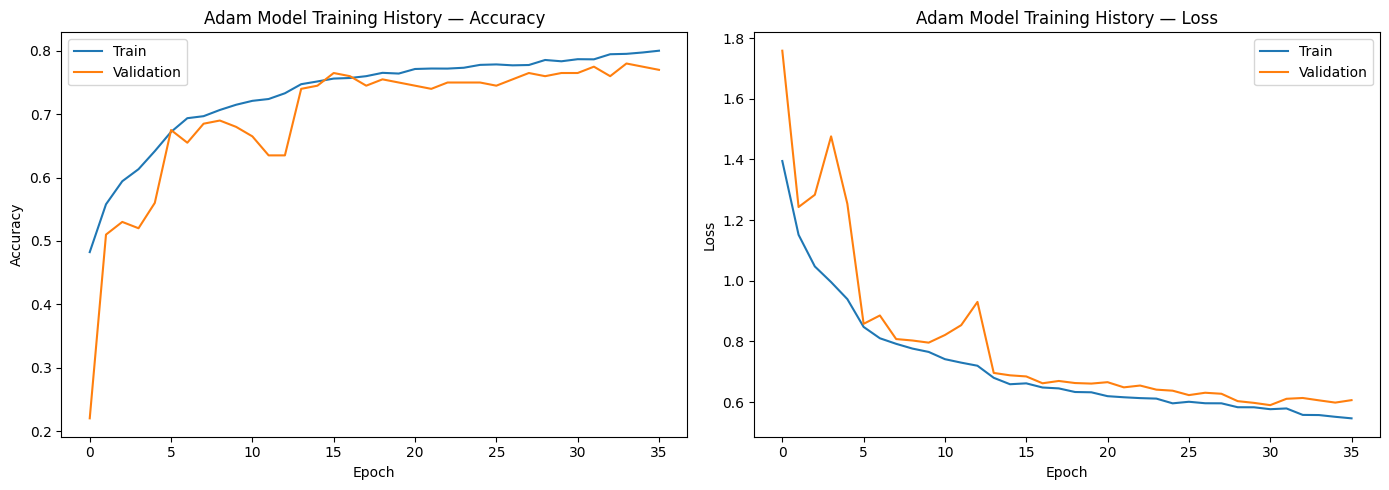

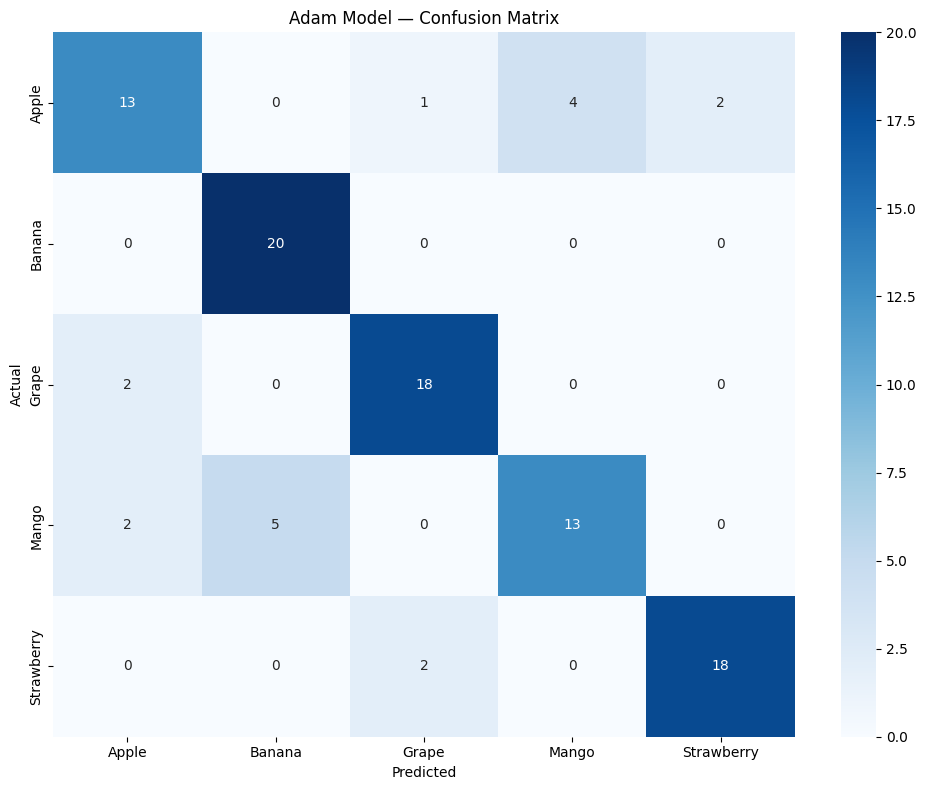


Adam Model — Classification Report
              precision    recall  f1-score   support

       Apple       0.76      0.65      0.70        20
      Banana       0.80      1.00      0.89        20
       Grape       0.86      0.90      0.88        20
       Mango       0.76      0.65      0.70        20
  Strawberry       0.90      0.90      0.90        20

    accuracy                           0.82       100
   macro avg       0.82      0.82      0.81       100
weighted avg       0.82      0.82      0.81       100



In [ ]:
adam_model = keras.models.load_model(
    "/content/drive/MyDrive/AI Sem6/FruitsClassification/adam_deeper_scratch_model.keras"
)

test_loss_adam, test_accuracy_adam = adam_model.evaluate(Test_Dataset)
print("Adam Model Test Accuracy:", test_accuracy_adam)

plot_history(history_adam, title="Adam Model Training History")
y_true_adam, y_pred_adam = evaluate_model(adam_model, Test_Dataset, Class_Names, title="Adam Model")

### SGD vs Adam Comparison Results



In [ ]:
print("\n--- Optimizer Comparison Summary ---")
print(f"SGD Model Test Accuracy: {test_accuracy_sgd:.4f}")
print(f"Adam Model Test Accuracy: {test_accuracy_adam:.4f}")


--- Optimizer Comparison Summary ---
SGD Model Test Accuracy: 0.7000
Adam Model Test Accuracy: 0.8200


#### Analysis of SGD vs Adam Performance


## 2. Ablation Study



### Training without Dropout



In [ ]:
def build_no_dropout_model(augmentation_layer, num_classes):
    model = keras.Sequential([
        layers.Input(shape=(224, 224, 3)),
        augmentation_layer,

        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(256, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.GlobalAveragePooling2D(),

        layers.Dense(256, activation="relu"),
        layers.BatchNormalization(),
        # Dropout layer removed

        layers.Dense(num_classes, activation="softmax")
    ])
    return model

no_dropout_model = build_no_dropout_model(Data_Augmentation_Scratch, Num_Classes)

no_dropout_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("No Dropout Model Summary:")
no_dropout_model.summary()

No Dropout Model Summary:


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ aug_scratch (Sequential)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 652,197 (2.49 MB)

 Trainable params: 650,725 (2.48 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [ ]:
no_dropout_callbacks = make_callbacks("/content/drive/MyDrive/AI Sem6/FruitsClassification/no_dropout_model.keras")
history_no_dropout, time_no_dropout = train_and_time(
    no_dropout_model,
    Train_Dataset,
    Validation_Dataset,
    epochs=50,
    callbacks=no_dropout_callbacks
)

Epoch 1/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.4734 - loss: 1.3551
Epoch 1: val_loss improved from None to 1.77436, saving model to /content/drive/MyDrive/WORk/AI2/archive/no_dropout_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/WORk/AI2/archive/no_dropout_model.keras
304/304 ━━━━━━━━━━━━━━━━━━━━ 69s 206ms/step - accuracy: 0.5267 - loss: 1.1883 - val_accuracy: 0.2650 - val_loss: 1.7744 - learning_rate: 5.0000e-04
Epoch 2/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.5873 - loss: 1.0113
Epoch 2: val_loss improved from 1.77436 to 1.22000, saving model to /content/drive/MyDrive/WORk/AI2/archive/no_dropout_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/WORk/AI2/archive/no_dropout_model.keras
304/304 ━━━━━━━━━━━━━━━━━━━━ 62s 204ms/step - accuracy: 0.6062 - loss: 0.9890 - val_accuracy: 0.5850 - val_loss: 1.2200 - learning_rate: 5.0000e-04
Epoch 3/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.6164 

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 146ms/step - accuracy: 0.8300 - loss: 0.4505
No Dropout Model Test Accuracy: 0.8299999833106995


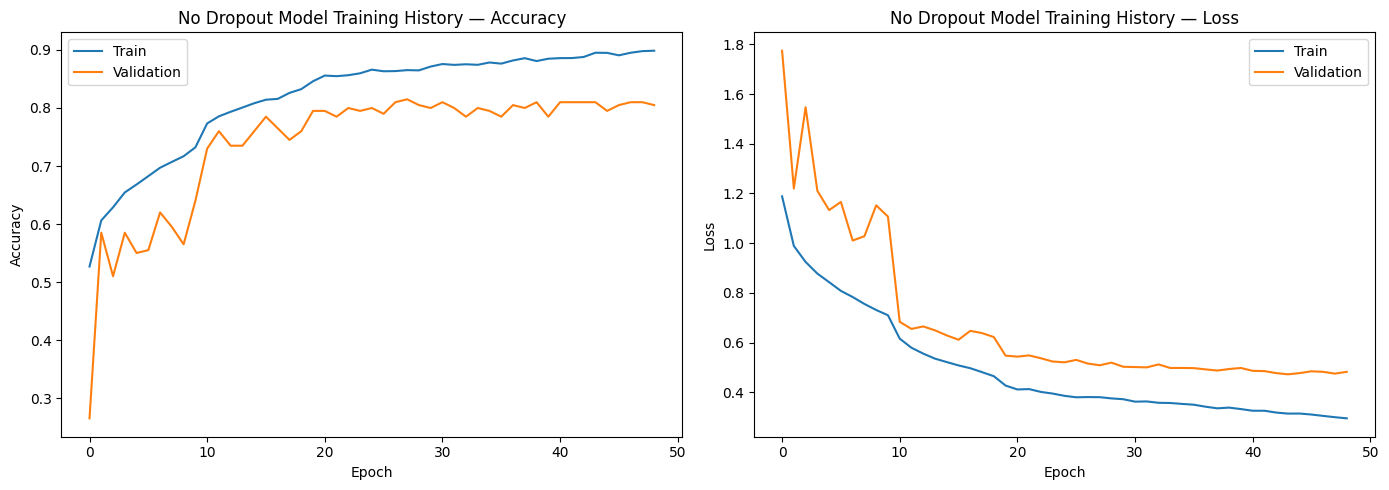

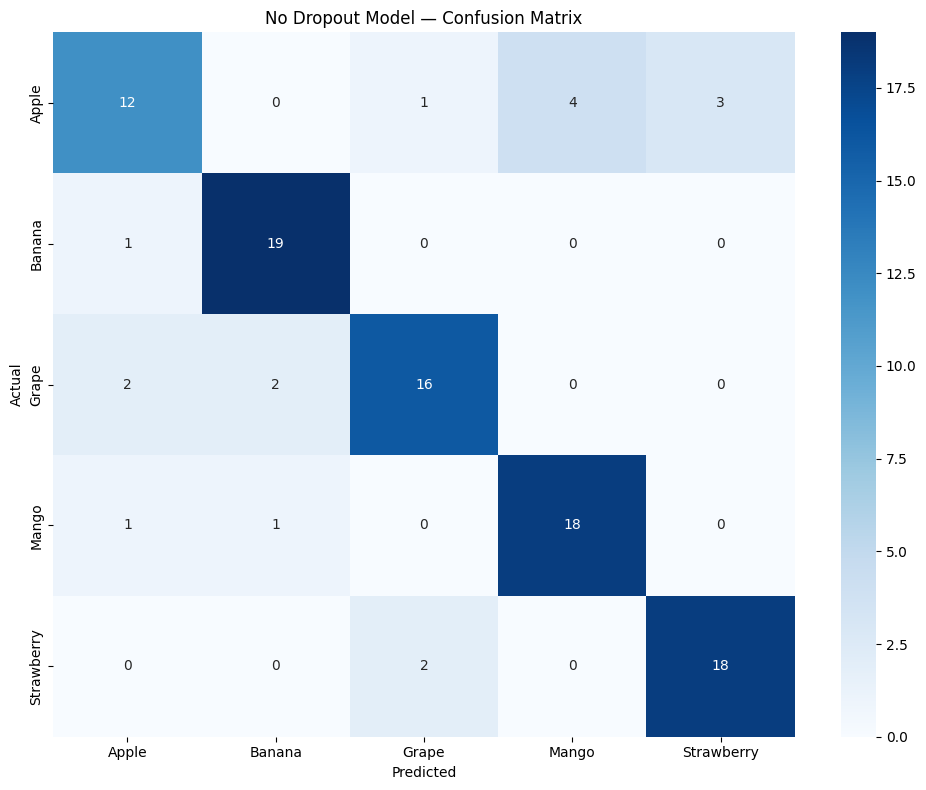


No Dropout Model — Classification Report
              precision    recall  f1-score   support

       Apple       0.75      0.60      0.67        20
      Banana       0.86      0.95      0.90        20
       Grape       0.84      0.80      0.82        20
       Mango       0.82      0.90      0.86        20
  Strawberry       0.86      0.90      0.88        20

    accuracy                           0.83       100
   macro avg       0.83      0.83      0.83       100
weighted avg       0.83      0.83      0.83       100



In [ ]:
no_dropout_model = keras.models.load_model(
    "/content/drive/MyDrive/WORk/AI2/archive/no_dropout_model.keras"
)

test_loss_no_dropout, test_accuracy_no_dropout = no_dropout_model.evaluate(Test_Dataset)
print("No Dropout Model Test Accuracy:", test_accuracy_no_dropout)

plot_history(history_no_dropout, title="No Dropout Model Training History")
y_true_no_dropout, y_pred_no_dropout = evaluate_model(no_dropout_model, Test_Dataset, Class_Names, title="No Dropout Model")

### Training without Batch Normalization



In [ ]:
def build_no_batchnorm_model(augmentation_layer, num_classes):
    model = keras.Sequential([
        layers.Input(shape=(224, 224, 3)),
        augmentation_layer,

        layers.Conv2D(32, 3, padding="same", activation="relu"),
        # BatchNormalization layer removed
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, padding="same", activation="relu"),
        # BatchNormalization layer removed
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(128, 3, padding="same", activation="relu"),
        # BatchNormalization layer removed
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(256, 3, padding="same", activation="relu"),
        # BatchNormalization layer removed
        layers.MaxPooling2D(),

        layers.GlobalAveragePooling2D(),

        layers.Dense(256, activation="relu"),
        # BatchNormalization layer removed
        layers.Dropout(0.4),

        layers.Dense(num_classes, activation="softmax")
    ])
    return model

no_batchnorm_model = build_no_batchnorm_model(Data_Augmentation_Scratch, Num_Classes)

no_batchnorm_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("No Batch Normalization Model Summary:")
no_batchnorm_model.summary()

No Batch Normalization Model Summary:


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ aug_scratch (Sequential)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 649,253 (2.48 MB)

 Trainable params: 649,253 (2.48 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
no_batchnorm_callbacks = make_callbacks("/content/drive/MyDrive/AI Sem6/FruitsClassification/no_batchnorm_model.keras")
history_no_batchnorm, time_no_batchnorm = train_and_time(
    no_batchnorm_model,
    Train_Dataset,
    Validation_Dataset,
    epochs=50,
    callbacks=no_batchnorm_callbacks
)

Epoch 1/50
254/304 ━━━━━━━━━━━━━━━━━━━━ 6s 131ms/step - accuracy: 0.3019 - loss: 1.5023

In [ ]:
no_batchnorm_model = keras.models.load_model(
    "/content/drive/MyDrive/AI Sem6/FruitsClassification/no_batchnorm_model.keras"
)

test_loss_no_batchnorm, test_accuracy_no_batchnorm = no_batchnorm_model.evaluate(Test_Dataset)
print("No Batch Normalization Model Test Accuracy:", test_accuracy_no_batchnorm)

plot_history(history_no_batchnorm, title="No Batch Normalization Model Training History")
y_true_no_batchnorm, y_pred_no_batchnorm = evaluate_model(no_batchnorm_model, Test_Dataset, Class_Names, title="No Batch Normalization Model")

### Ablation Study Summary



In [ ]:
print("\n--- Ablation Study Summary ---")
print(f"Full Deeper Scratch Model (Adam) Test Accuracy: {test_accuracy:.4f}")
print(f"No Dropout Model Test Accuracy: {test_accuracy_no_dropout:.4f}")
print(f"No Batch Normalization Model Test Accuracy: {test_accuracy_no_batchnorm:.4f}")

#### Analysis of Ablation Study Results



## 3. Training Time Comparison Table



In [ ]:
print("\n--- Training Time Comparison ---")
print("{:<30} {:>10}".format("Model", "Time (m:s)"))
print("-" * 45)

# Assuming `time_part2`, `time_baseline`, `time_scratch`, `time_sgd`, `time_adam`, `time_no_dropout`, `time_no_batchnorm` are defined

def format_time(seconds):
    mins, secs = divmod(int(seconds), 60)
    return f"{mins}m {secs}s"

# The original 'history' variable was for Part2Model, let's use the time variable from there
# We'll assume the time_scratch is the 'full model' time from the previous run if history_scratch was interrupted.
# If you rerun all cells, ensure these time variables are correctly populated.

# For Part2Model (Transfer Learning)
print("{:<30} {:>10}".format("Transfer Learning (Part2)", format_time(time_part2)))
# For Baseline CNN
print("{:<30} {:>10}".format("Baseline CNN", format_time(time_baseline)))
# For Deeper Scratch Model (Original Adam Training)
print("{:<30} {:>10}".format("Deeper Scratch (Adam)", format_time(time_scratch)))
# For Deeper Scratch Model (SGD)
print("{:<30} {:>10}".format("Deeper Scratch (SGD)", format_time(time_sgd)))
# For Deeper Scratch Model (Adam for comparison)
print("{:<30} {:>10}".format("Deeper Scratch (Adam Comp)", format_time(time_adam)))
# For Ablation: No Dropout
print("{:<30} {:>10}".format("Deeper Scratch (No Dropout)", format_time(time_no_dropout)))
# For Ablation: No Batch Normalization
print("{:<30} {:>10}".format("Deeper Scratch (No BatchNorm)", format_time(time_no_batchnorm)))


## 4. Sample Image Inference



In [ ]:
import random

# Choose the best model for inference, e.g., the Adam-optimized deeper scratch model
inference_model = adam_model # Or sgd_model, or Part2Model based on your comparison

plt.figure(figsize=(10, 10))

# Get a fresh batch from the test dataset for unbiased sampling
# Ensure Test_Dataset is not cached with `cache()` or if it is, that it's correctly reset or reloaded
# For reliable random sampling, it's often best to iterate over an un-cached dataset or collect samples.

# To get truly random images, we'll iterate through the dataset and collect some, then pick from them.
all_test_images = []
all_test_labels = []
for images, labels in Test_Dataset.unbatch(): # Unbatch to get individual image/label pairs
    all_test_images.append(images.numpy())
    all_test_labels.append(labels.numpy())

# Select 9 random indices
random_indices = random.sample(range(len(all_test_images)), 9)

for i, idx in enumerate(random_indices):
    image = all_test_images[idx]
    true_label_idx = all_test_labels[idx]

    # Make prediction (add batch dimension for single image inference)
    prediction = inference_model.predict(np.expand_dims(image, axis=0), verbose=0)
    predicted_label_idx = np.argmax(prediction)

    plt.subplot(3, 3, i + 1)
    plt.imshow(image) # Already normalized, imshow can handle float [0,1]

    true_label_name = Class_Names[true_label_idx]
    predicted_label_name = Class_Names[predicted_label_idx]

    color = "green" if predicted_label_idx == true_label_idx else "red"
    title = f"True: {true_label_name}\nPred: {predicted_label_name}"
    plt.title(title, color=color)
    plt.axis("off")

plt.tight_layout()
plt.suptitle("Sample Image Inference (Adam Model)", y=1.02, fontsize=16)
plt.show()